# Exercise 10: MPI parallelization

**Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a Genetic Search with (up to) 11 parallel GA searches of the optimal path: each node should perform an independent GA search, the so-called Continent, but every generations the Continents should exchange their best individuals randomly.
Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.
If your choice in Exercise 10.1 is option 1, do you improve with respect using the same number of computing cores but with independent GA searches ?**


My Travelling Salesman code was based on a struct *gene*, storing the index and position of each city, and two main classes: the *chromosome*, which represents a path between cities with its respective travelled distance(cost), and the *GeneticOptimizer*, which operates  the actual optimization. 
My parallel algorithm maintains the same structure, using the MPI libraries to add *send* and *receive* methods to the chromosome, which when called send/receive the number of genes the chromosome contains, their content (maintaining their order inside the chromosome), and the cost.
The algorithm follows these steps:
- create a different random generator and *GeneticOptimizer* object for each process
- optimize each generator separately for **50 generations** obtaining the best chromosome
- in the rank 0 process, generate the random exchange pairs and broadcast them to all processes
- each process sends its best chromosome to the its assigned destination
- repeat the optimization+migration for **200** times

In the following plots I show the the best chromosome cost for each process at every migration, comparing the case in which the processes are are allowed to evolve independently (just optimization, no migration) with the 

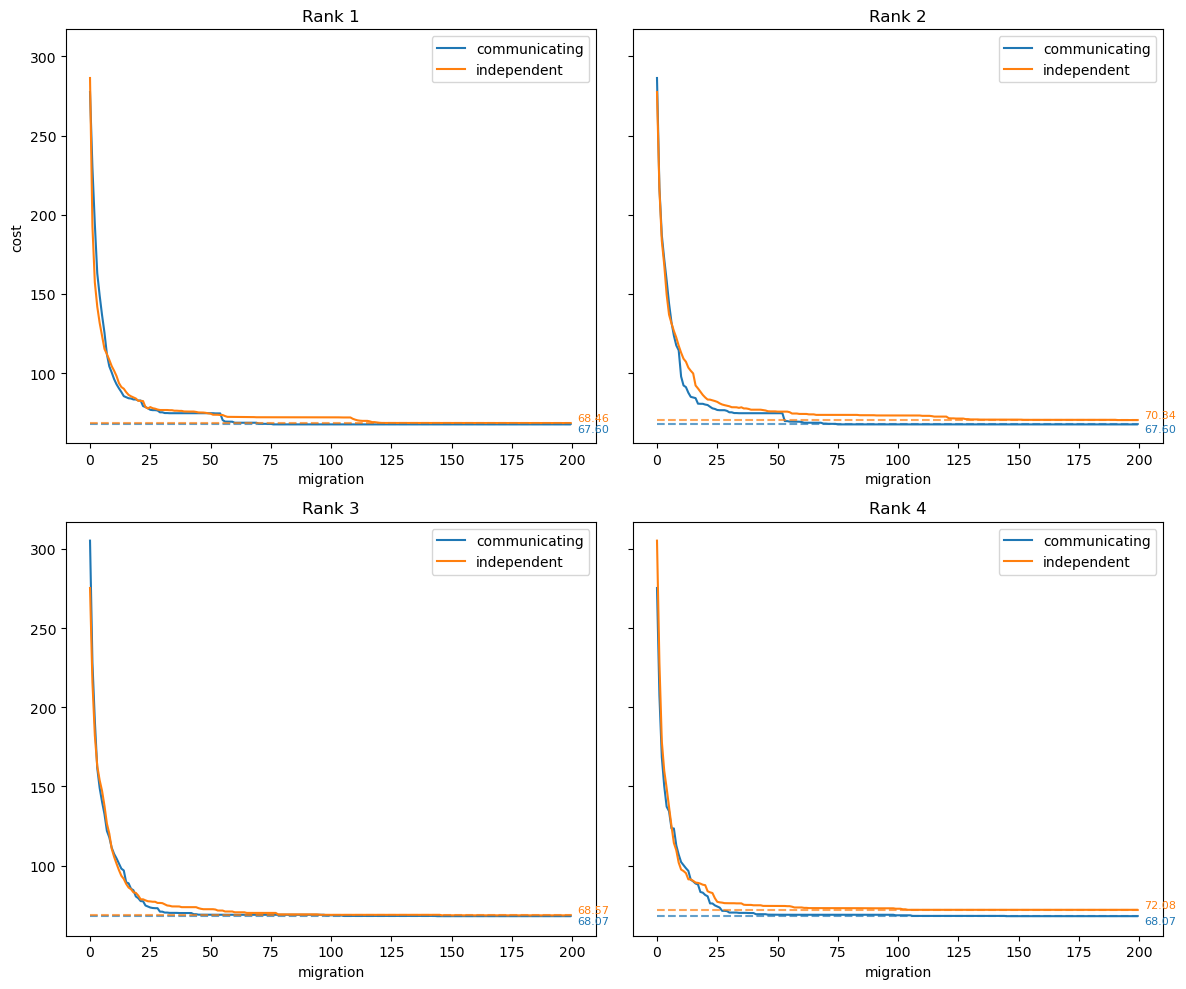

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Dati indipendenti
dfic = pd.read_csv('./OUTPUT/indep_costs.csv', sep='\t')

fig, axes = plt.subplots(2, 2, figsize=(12,10), sharey=True)
axes = axes.flatten()

costs = []
indep_costs =[]
for i in range(4):
    dfc = pd.read_csv(f'./OUTPUT/costs_{i}.csv', sep='\t')
    
    # linee principali
    line_comm, = axes[i].plot(dfc['gen'], dfc['cost'], label='communicating')
    line_ind,  = axes[i].plot(dfic['migr'], dfic[f'rank{i}'], label='independent')

    # colori coerenti
    color_comm = line_comm.get_color()
    color_ind = line_ind.get_color()

    # valori finali
    y_comm = dfc['cost'].iloc[-1]
    y_ind = dfic[f'rank{i}'].iloc[-1]
    costs.append(y_comm)
    indep
    # linee orizzontali dashed
    axes[i].hlines(y_comm, 0, 200, linestyle='--', alpha=0.7, color=color_comm)
    axes[i].hlines(y_ind, 0, 200, linestyle='--', alpha=0.7, color=color_ind)

    # etichette numeriche vicino alle linee
    axes[i].text(202, y_comm, f'{y_comm:.2f}', va='top', fontsize=8, color=color_comm)
    axes[i].text(202, y_ind, f'{y_ind:.2f}', va='bottom', fontsize=8, color=color_ind)

    axes[i].set_xlabel('migration')
    axes[i].set_title(f'Rank {i+1}')
    axes[i].legend()

axes[0].set_ylabel('cost')
plt.tight_layout()
plt.show()


/tmp/ipykernel_13196/3469603798.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


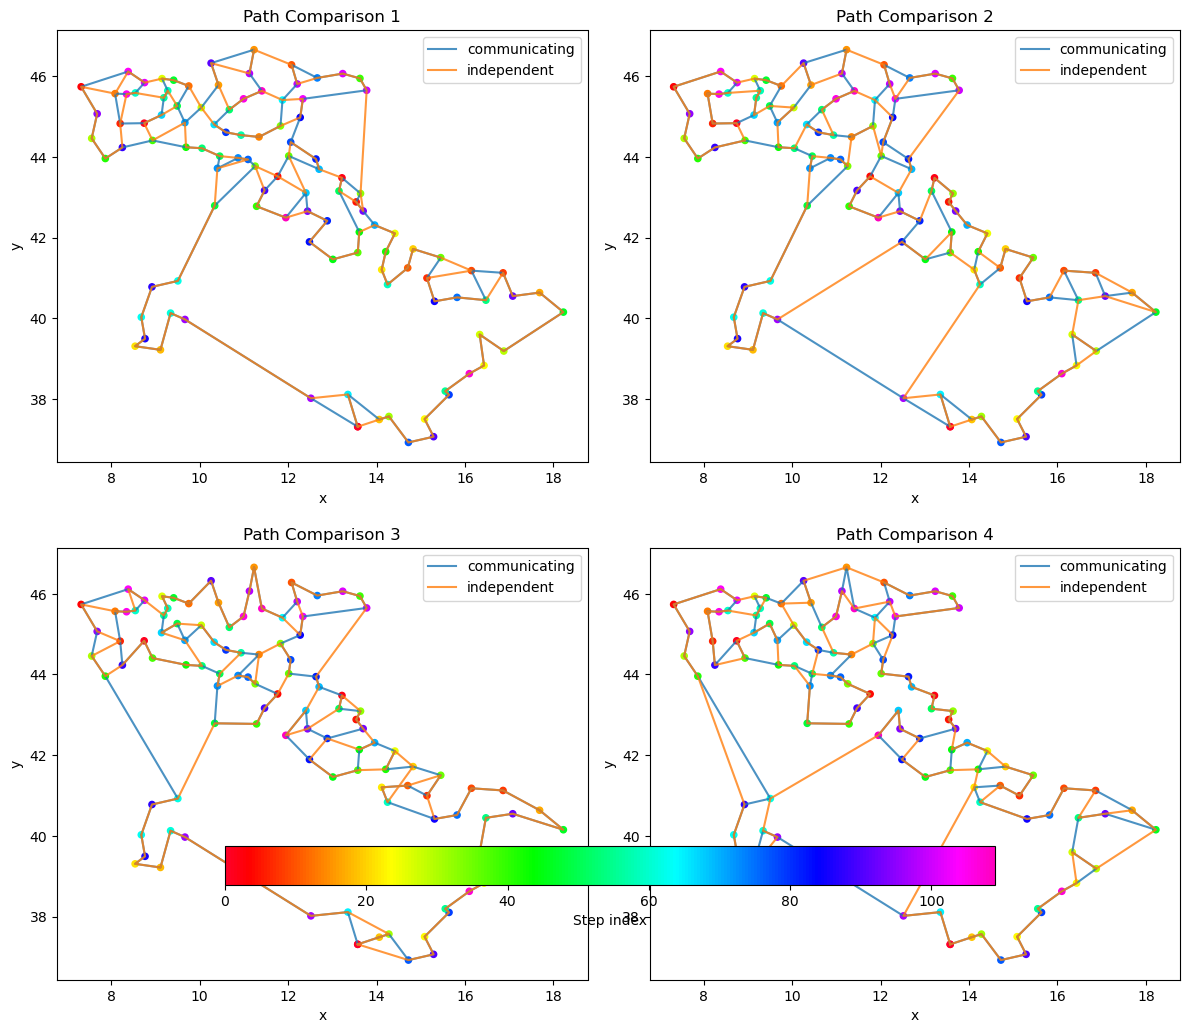

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()


for i in range(4):
    # communicating
    df_comm = pd.read_csv(f'./OUTPUT/best_path_{i}.csv', sep='\t')
    # independent
    df_ind = pd.read_csv(f'./OUTPUT/indep_best_path_{i}.csv', sep='\t')

    # plot communicating path
    comm_line = axes[i].plot(df_comm['x'], df_comm['y'], 
                              label='communicating',
                             alpha=0.8, markersize=4)
    # plot independent path
    ind_line = axes[i].plot(df_ind['x'], df_ind['y'], 
                             label='independent',
                            alpha=0.8, markersize=4)

    # scatter per indicare la progressione temporale (stesso colormap per coerenza)
    sc1 = axes[i].scatter(df_comm['x'], df_comm['y'], c=df_comm['index'], cmap='gist_rainbow', s=20)
    #sc2 = axes[i].scatter(df_ind['x'], df_ind['y'], c=df_ind['index'], cmap='gist_rainbow', s=20, marker='s')


    axes[i].set_title(f'Path Comparison {i+1}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].legend()

# barra colore condivisa
fig.colorbar(sc1, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05, label='Step index')

plt.tight_layout()
plt.show()


[np.float64(67.5988), np.float64(67.5988), np.float64(68.0715), np.float64(68.0715)]
[np.float64(68.4553), np.float64(70.3378), np.float64(68.5696), np.float64(72.0818)]


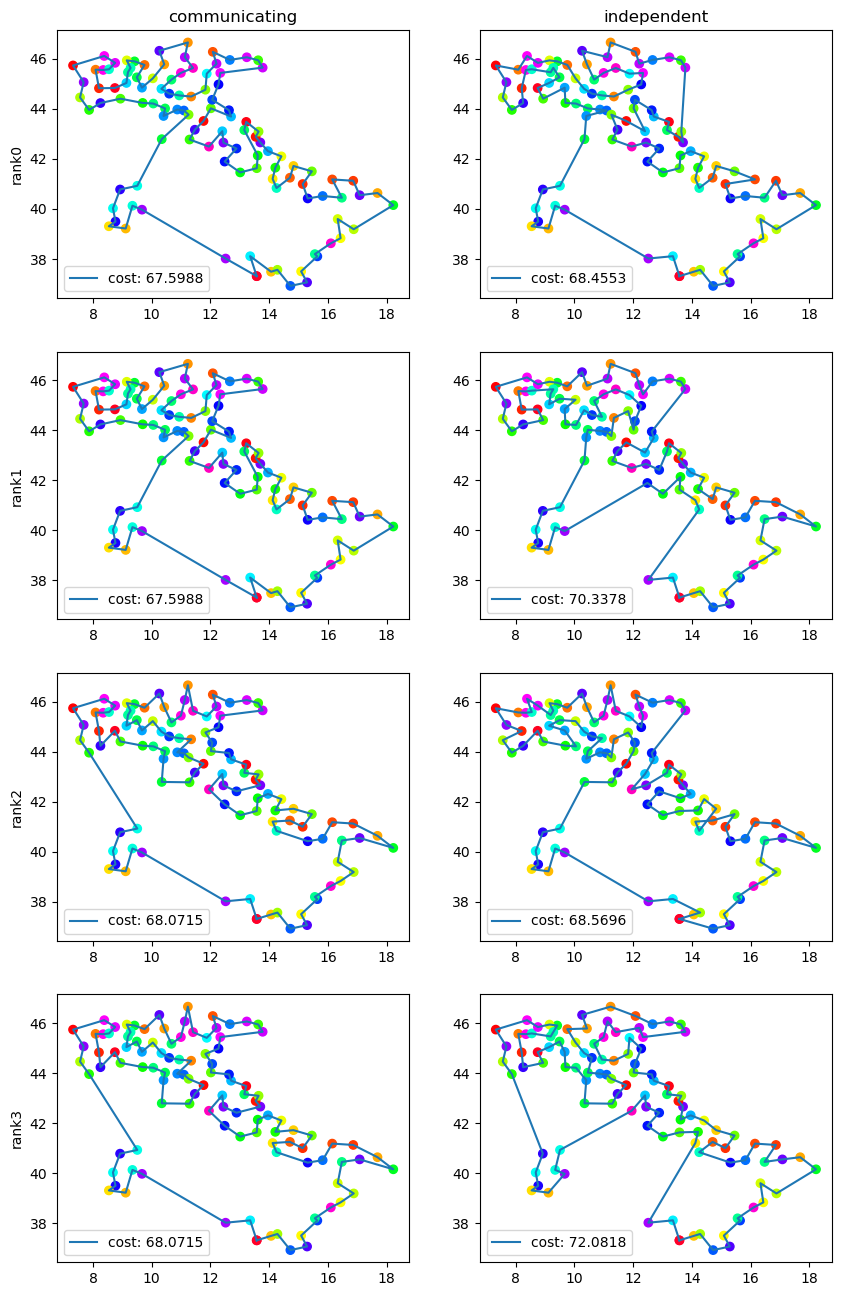

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

fig,ax = plt.subplots(4,2,figsize=(10,16))

print(costs)
print(indep_costs)
for i in range(4):
    df = pd.read_csv(f'./OUTPUT/best_path_{i}.csv',sep ='\t')
    
    df1 = pd.read_csv(f'./OUTPUT/indep_best_path_{i}.csv',sep ='\t')
    ax[i,0].plot(df['x'],df['y'],label=f'cost: {costs[i]}')
    ax[i,0].set_ylabel(f'rank{i}')

    ax[i,1].plot(df1['x'],df1['y'],label=f'cost: {indep_costs[i]}')
    sc = ax[i,0].scatter(df['x'],df['y'],marker = 'o',c=df['index'],cmap = 'gist_rainbow')
    sc = ax[i,1].scatter(df['x'],df['y'],marker = 'o',c=df['index'],cmap = 'gist_rainbow')
    ax[i,0].legend()
    ax[i,1].legend()

ax[0,0].set_title('communicating')
ax[0,1].set_title('independent')

plt.show()


There is no deterministic way to establish if the global minimum was reached with the optimization, but there are some observations that can be made that point towards considering the communicating processes method as the most effective:
- from the cost plots we can see that the communicating optimization reaches the final result (minimum) faster than the independent processes for all ranks
- The best path that are obtained in the end have lower costs for all the communicating cases
- The ranks 0 and 1 reach the same result in the communicating case, and by looking at the path in figure 2 one can assume it is a good candidate for a global minimum

A possible way to further expl